In [1]:
"""
Name: Module 6 Academic Success.py
Assignment 3 and 4 - logit regression
"""

'\nName: Module 6 Academic Success.py\nAssignment 3 and 4 - logit regression\n'

In [2]:
import matplotlib.pyplot as plt
import numpy
import pandas
import sys
from scipy.stats import chi2
import os

# Find CSP571 folder by walking up from cwd
cwd = os.path.abspath(os.getcwd())
search_dir = cwd
base_dir = None
for _ in range(5):
    candidate = os.path.join(search_dir, "CSP571")
    if os.path.isdir(candidate) and os.path.isfile(os.path.join(candidate, "raw", "Utility.py")):
        base_dir = candidate
        break
    search_dir = os.path.dirname(search_dir)

if base_dir is None:
    raise FileNotFoundError("Could not locate CSP571/raw/Utility.py from current working directory.")

sys.path.append(os.path.join(base_dir, "raw"))
import Utility

# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)
pandas.options.display.float_format = '{:,.10f}'.format



In [18]:


from statsmodels.discrete.discrete_model import MNLogit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn


def MNLogisticModel(X_train, y_train):
    """
    Fit a multinomial logit regression model.
    
    Parameters:
    -----------
    X_train : pd.DataFrame
        Design matrix (features) including intercept if needed
    y_train : pd.Series or array
        Target variable (categorical)
    
    Returns:
    --------
    model : fitted MNLogit model
    """
    # Fit the multinomial logit model directly (not formula-based)
    model = MNLogit(y_train, X_train).fit(disp=0)
    
    print(model.summary())
    
    # Print model equation
    print("\n" + "="*70)
    print("MODEL EQUATION")
    print("="*70)
    params = model.params
    
    # For MNLogit, params is a DataFrame with:
    # - Index: predictor/variable names
    # - Columns: outcome class labels (or numeric indices for binary)
    for class_col in params.columns:
        outcome_label = y_train.unique()[class_col] if isinstance(class_col, int) and len(y_train.unique()) == 2 else class_col
        print(f"\nFor outcome {outcome_label}:")
        print(f"  log(odds) = ", end="")
        
        terms = []
        for pred_name in params.index:
            coef = params.loc[pred_name, class_col]
            if len(terms) == 0:
                terms.append(f"{coef:.6f}*{pred_name}")
            else:
                sign = "+" if coef >= 0 else "-"
                terms.append(f" {sign} {abs(coef):.6f}*{pred_name}")
        print("".join(terms))
    
    print("\n" + "="*70)
    
    # Get predictions
    pred_probs = model.predict(X_train)
    y_pred = pred_probs.idxmax(axis=1)
    
    # Calculate performance metrics
    accuracy = accuracy_score(y_train, y_pred)
    precision = precision_score(y_train, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_train, y_pred, average='weighted', zero_division=0)
    
    # Print performance metrics
    print("\n" + "="*70)
    print("MODEL PERFORMANCE METRICS")
    print("="*70)
    print(f"Accuracy:  {accuracy:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Recall:    {recall:.6f}")
    print("="*70)
    
    # Confusion matrix
    cm = confusion_matrix(y_train, y_pred)
    
    # Print confusion matrix in text format
    print("\n" + "="*70)
    print("CONFUSION MATRIX")
    print("="*70)
    cm_df = pandas.DataFrame(cm, 
                             index=[f'Actual {cls}' for cls in y_train.unique()],
                             columns=[f'Predicted {cls}' for cls in y_train.unique()])
    print(cm_df)
    print("="*70)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6), dpi=150)
    seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title("Confusion Matrix - Multinomial Logit")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    return model

#### FACE DATA AND LOGIT REGRESSION

In [19]:
face = pandas.read_csv(r'data\Face.csv')

face["IS_NOSE"] = (face["feature"].astype(int) == 3).astype(int)
face.drop(columns=["feature"], inplace=True)
face

,horizontal,vertical,IS_NOSE
0,-1.2000000000,0.7630000000,0
1,-1.2000000000,0.7630000000,0
2,-1.1500000000,0.5430000000,0
3,-1.1500000000,0.9830000000,0
4,-1.1000000000,0.4630000000,0
...,...,...,...
124,0.2000000000,-1.5370000000,0
125,0.4000000000,-1.5870000000,0
126,0.6000000000,-1.6370000000,0
127,0.8000000000,-1.6870000000,0


                          MNLogit Regression Results                          
Dep. Variable:                IS_NOSE   No. Observations:                  129
Model:                        MNLogit   Df Residuals:                      127
Method:                           MLE   Df Model:                            1
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                 -0.1966
Time:                        14:57:01   Log-Likelihood:                -85.118
converged:                       True   LL-Null:                       -71.135
Covariance Type:            nonrobust   LLR p-value:                     1.000
 IS_NOSE=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
horizontal  1.403e-17      0.270    5.2e-17      1.000      -0.528       0.528
vertical      -0.4964      0.175     -2.831      0.005      -0.840      -0.153

MODEL EQUATION

For outcome 0:
  log(odds) = 0.0000

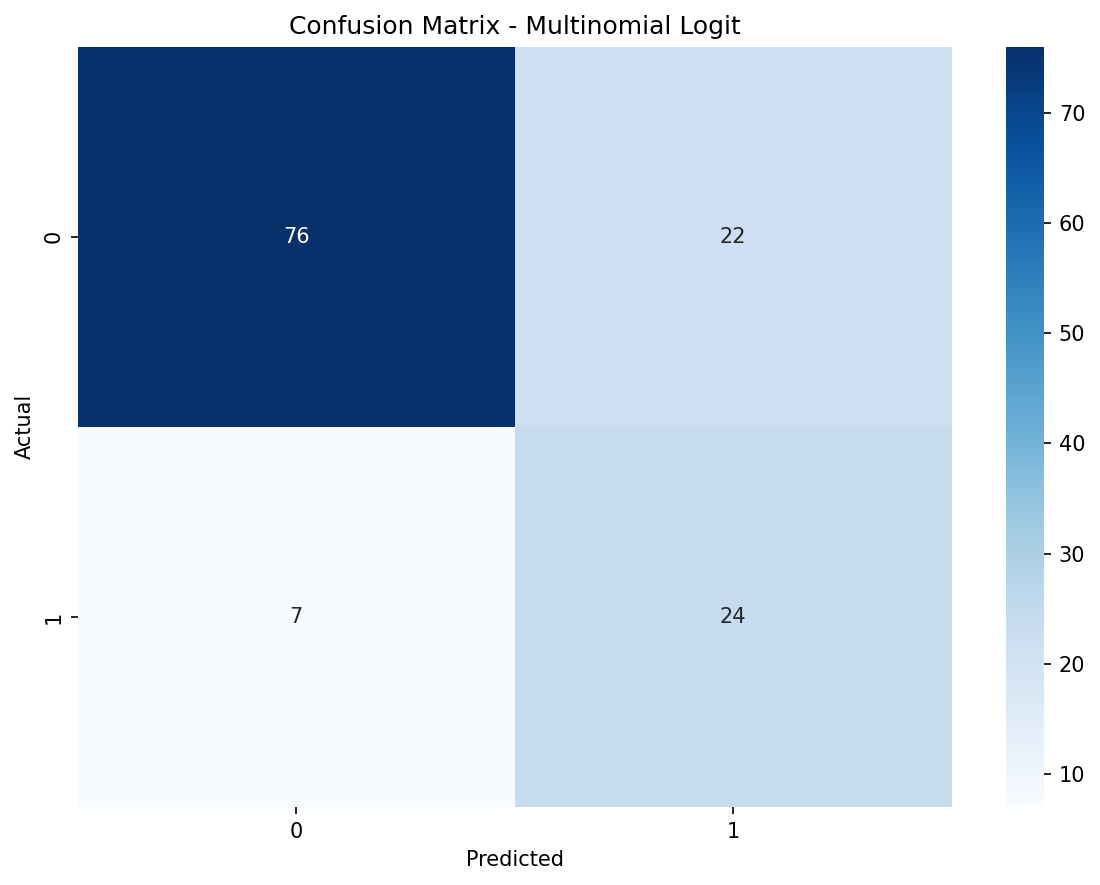

In [20]:
y_train = face["IS_NOSE"]
X_train = face.drop(columns=["IS_NOSE"])
nose_model = MNLogisticModel(X_train, y_train)

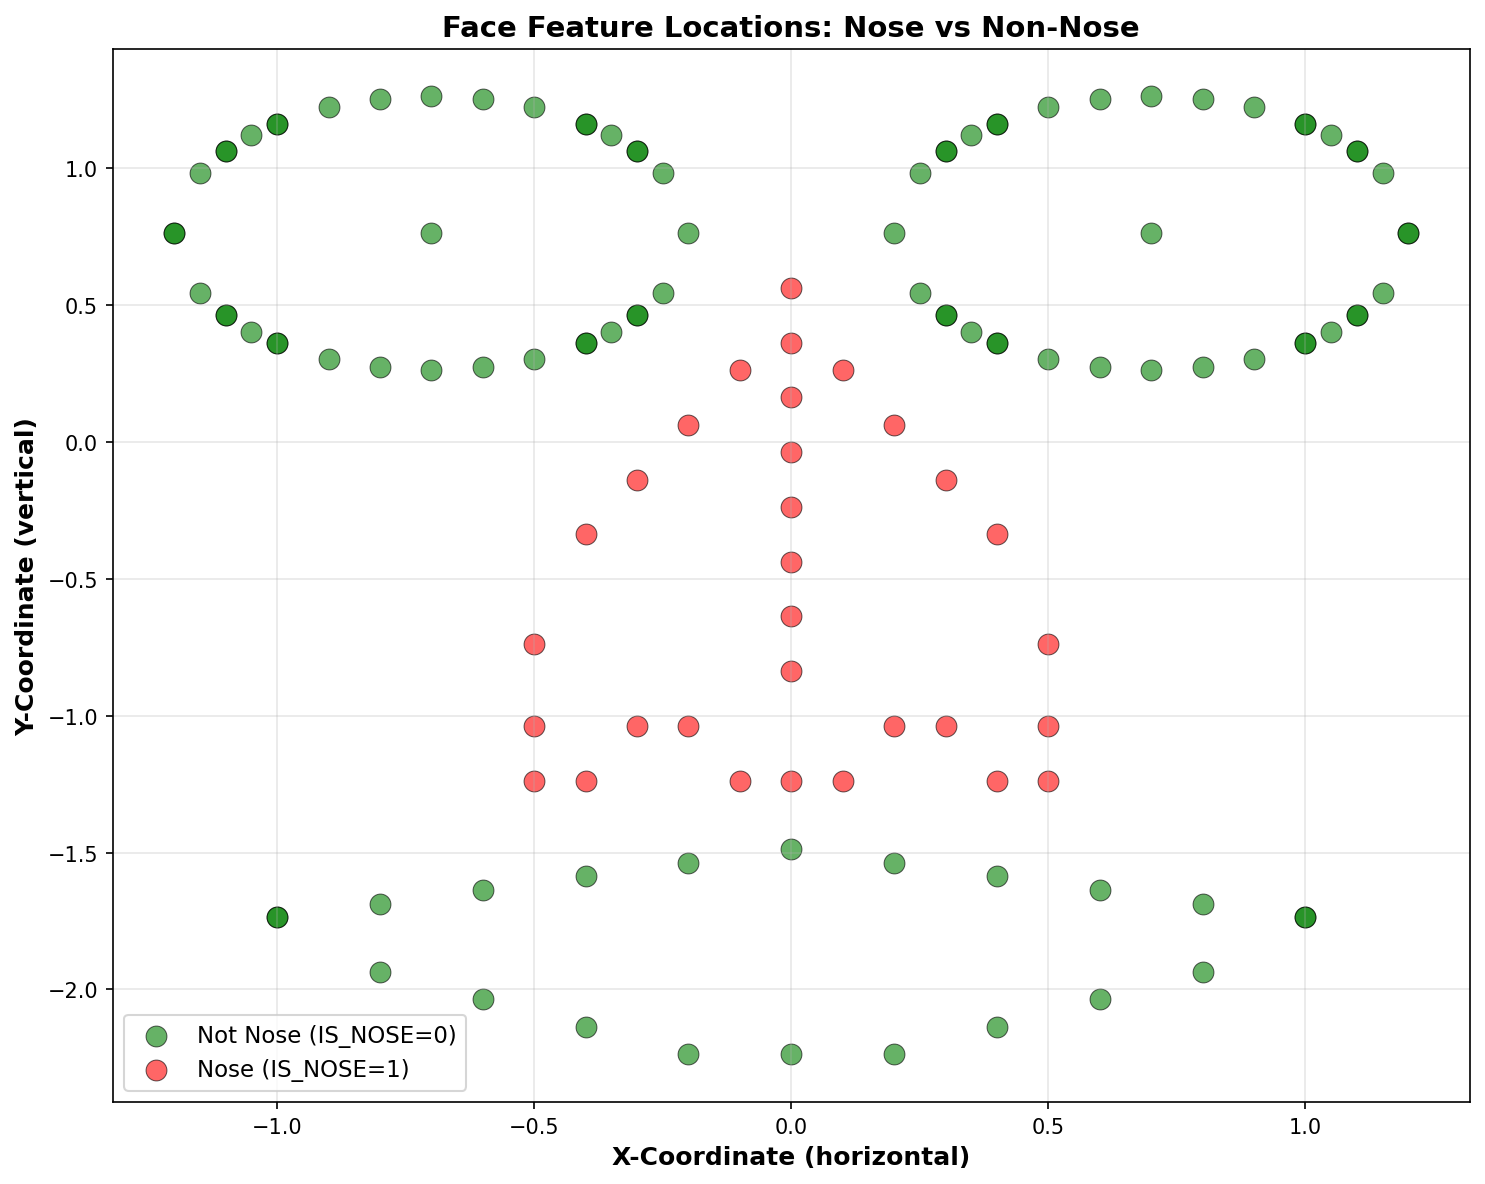

In [21]:
# Generate a scatterplot of the y-coordinate (vertical) and x-coordinate (horizontal)
# Color-coded by IS_NOSE values with proper legend labels

plt.figure(figsize=(10, 8), dpi=150)

# Plot points for each class
for nose_class, color, label in [(0, 'green', 'Not Nose (IS_NOSE=0)'), (1, 'red', 'Nose (IS_NOSE=1)')]:
    mask = face['IS_NOSE'] == nose_class
    plt.scatter(face.loc[mask, 'horizontal'], face.loc[mask, 'vertical'], 
                c=color, label=label, s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('X-Coordinate (horizontal)', fontsize=12, fontweight='bold')
plt.ylabel('Y-Coordinate (vertical)', fontsize=12, fontweight='bold')
plt.title('Face Feature Locations: Nose vs Non-Nose', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


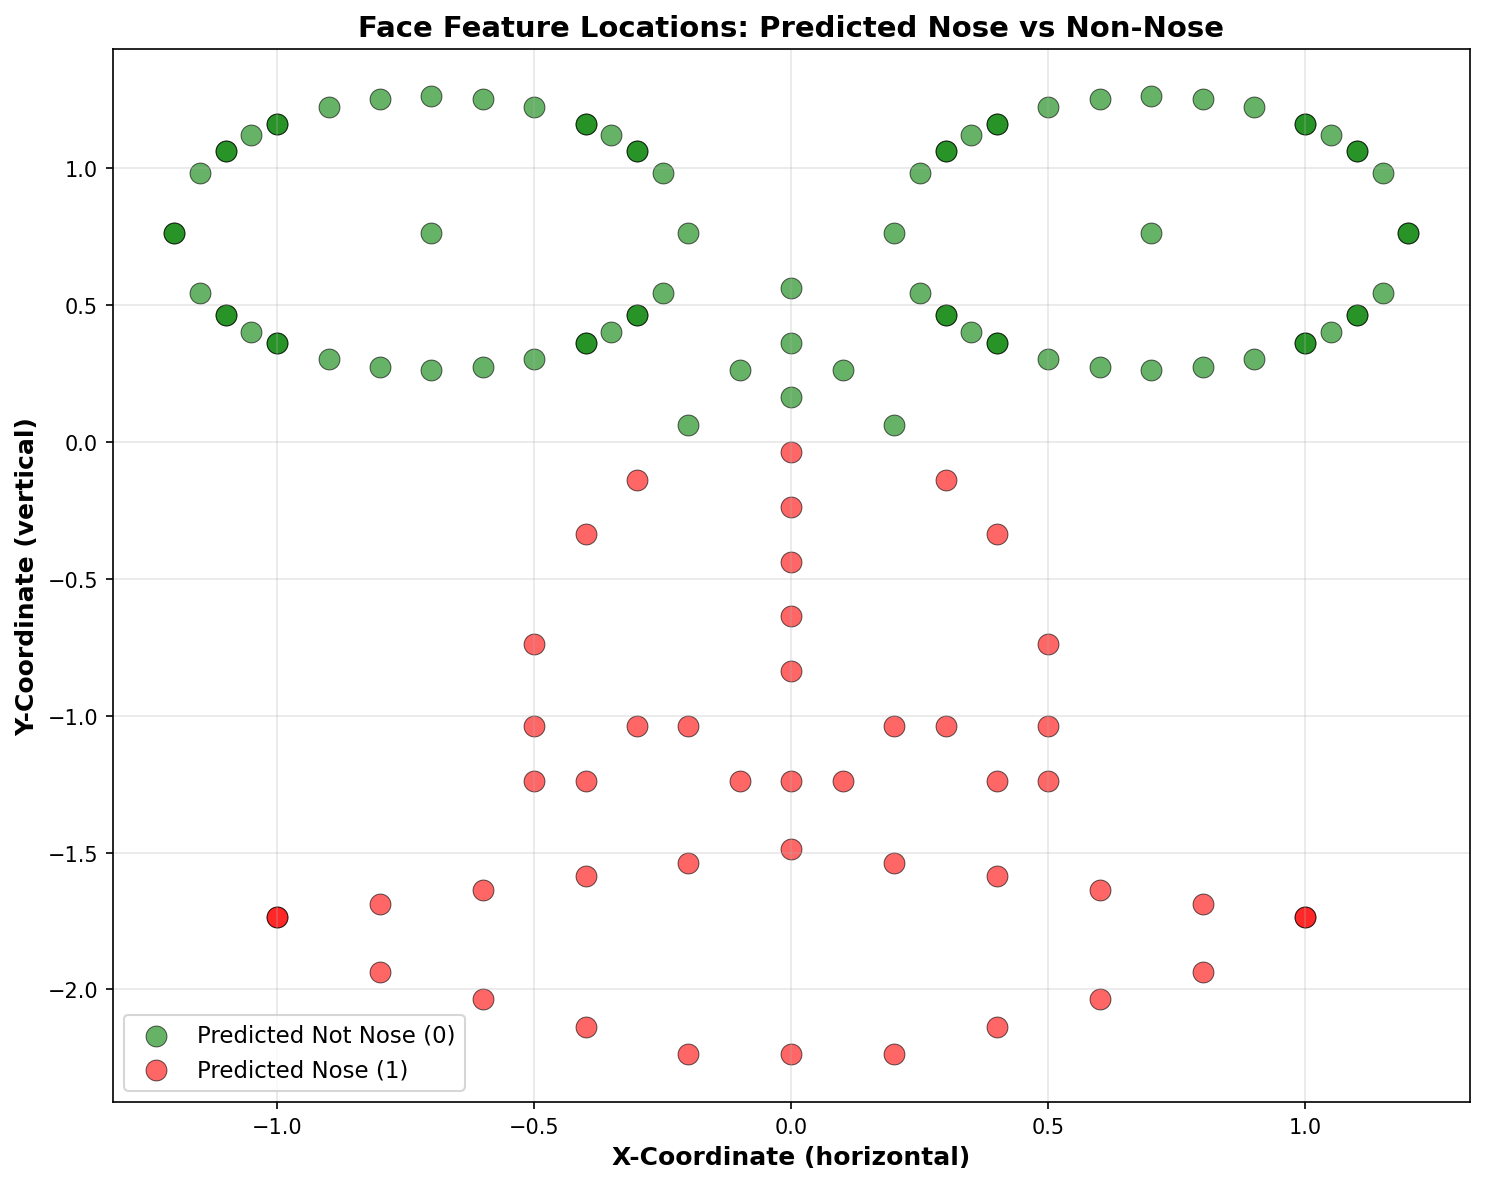

In [22]:
# Generate predictions from the model and plot with predicted IS_NOSE values
pred_probs = nose_model.predict(X_train)
y_pred = pred_probs.idxmax(axis=1)

plt.figure(figsize=(10, 8), dpi=150)

# Plot points for each predicted class
for nose_class, color, label in [(0, 'green', 'Predicted Not Nose (0)'), (1, 'red', 'Predicted Nose (1)')]:
    mask = y_pred == nose_class
    plt.scatter(face.loc[mask, 'horizontal'], face.loc[mask, 'vertical'], 
                c=color, label=label, s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('X-Coordinate (horizontal)', fontsize=12, fontweight='bold')
plt.ylabel('Y-Coordinate (vertical)', fontsize=12, fontweight='bold')
plt.title('Face Feature Locations: Predicted Nose vs Non-Nose', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# Create a new model using polar coordinates
# Copy face dataframe to face_polar
face_polar = face.copy()
face_polar

# Transform Cartesian coordinates to Polar coordinates
# r = sqrt((x + 0.2)^2 + y^2)
# theta = arctan(y / (x + 0.2)) with -π ≤ θ ≤ π

# Calculate r and theta
face_polar['r'] = numpy.sqrt((face_polar['horizontal'] + 0.2)**2 + face_polar['vertical']**2)
face_polar['theta'] = numpy.arctan2(face_polar['vertical'], face_polar['horizontal'] + 0.2)

# Drop the Cartesian coordinates (keep only polar coordinates and IS_NOSE)
face_polar = face_polar.drop(columns=['horizontal', 'vertical'])

# Display the transformed dataframe
face_polar


,IS_NOSE,r,theta
0,0,1.2578429950,2.4898233281
1,0,1.2578429950,2.4898233281
2,0,1.0942344356,2.6223331864
3,0,1.3670365760,2.3391242395
4,0,1.0121111599,2.6664563764
...,...,...,...
124,0,1.5881967762,-1.3161967021
125,0,1.6966346100,-1.2093352657
126,0,1.8220233259,-1.1162304514
127,0,1.9611142241,-1.0357112753


                          MNLogit Regression Results                          
Dep. Variable:                IS_NOSE   No. Observations:                  129
Model:                        MNLogit   Df Residuals:                      127
Method:                           MLE   Df Model:                            1
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.4453
Time:                        14:57:48   Log-Likelihood:                -39.457
converged:                       True   LL-Null:                       -71.135
Covariance Type:            nonrobust   LLR p-value:                 1.725e-15
 IS_NOSE=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
r             -1.6727      0.298     -5.609      0.000      -2.257      -1.088
theta         -1.3874      0.298     -4.662      0.000      -1.971      -0.804

MODEL EQUATION

For outcome 0:
  log(odds) = -1.672

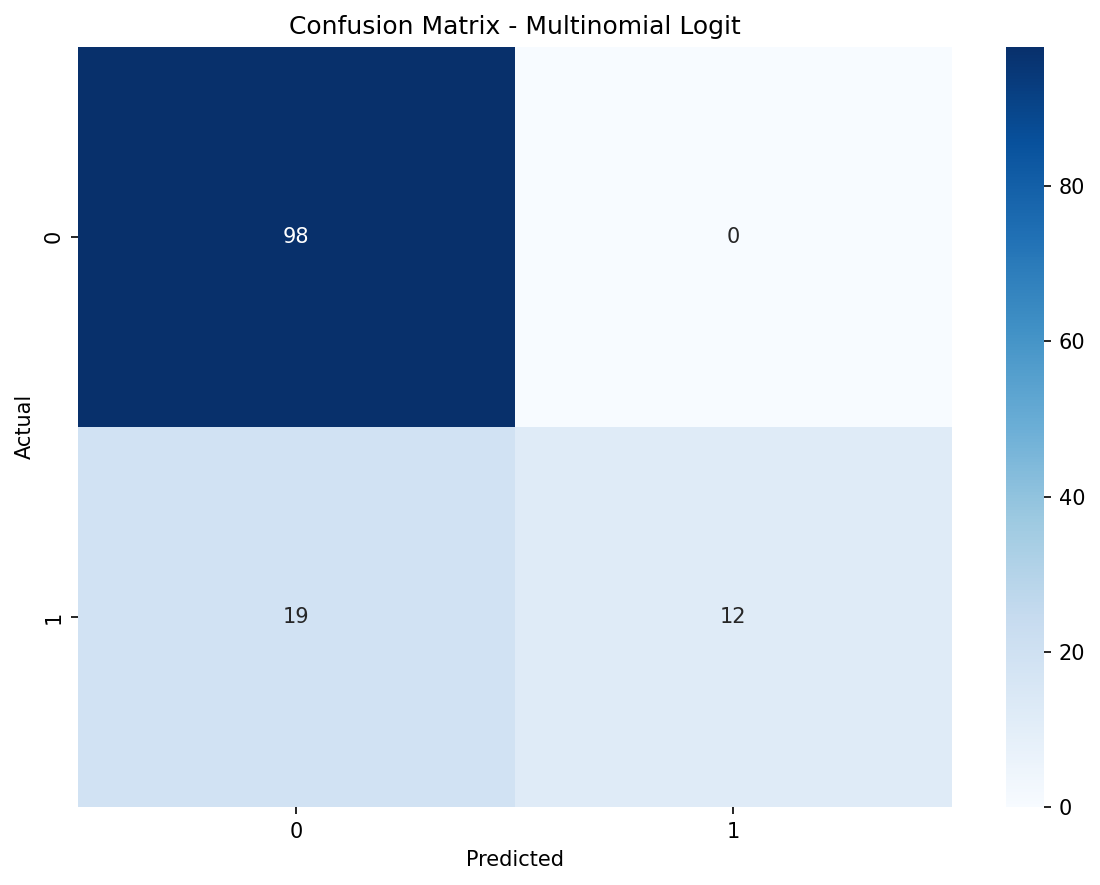

In [24]:
# Train the MNLogit model using polar coordinates (r and theta)
y_train_polar = face_polar["IS_NOSE"]
X_train_polar = face_polar.drop(columns=["IS_NOSE"])

# Fit the model with polar coordinates
nose_model_polar = MNLogisticModel(X_train_polar, y_train_polar)


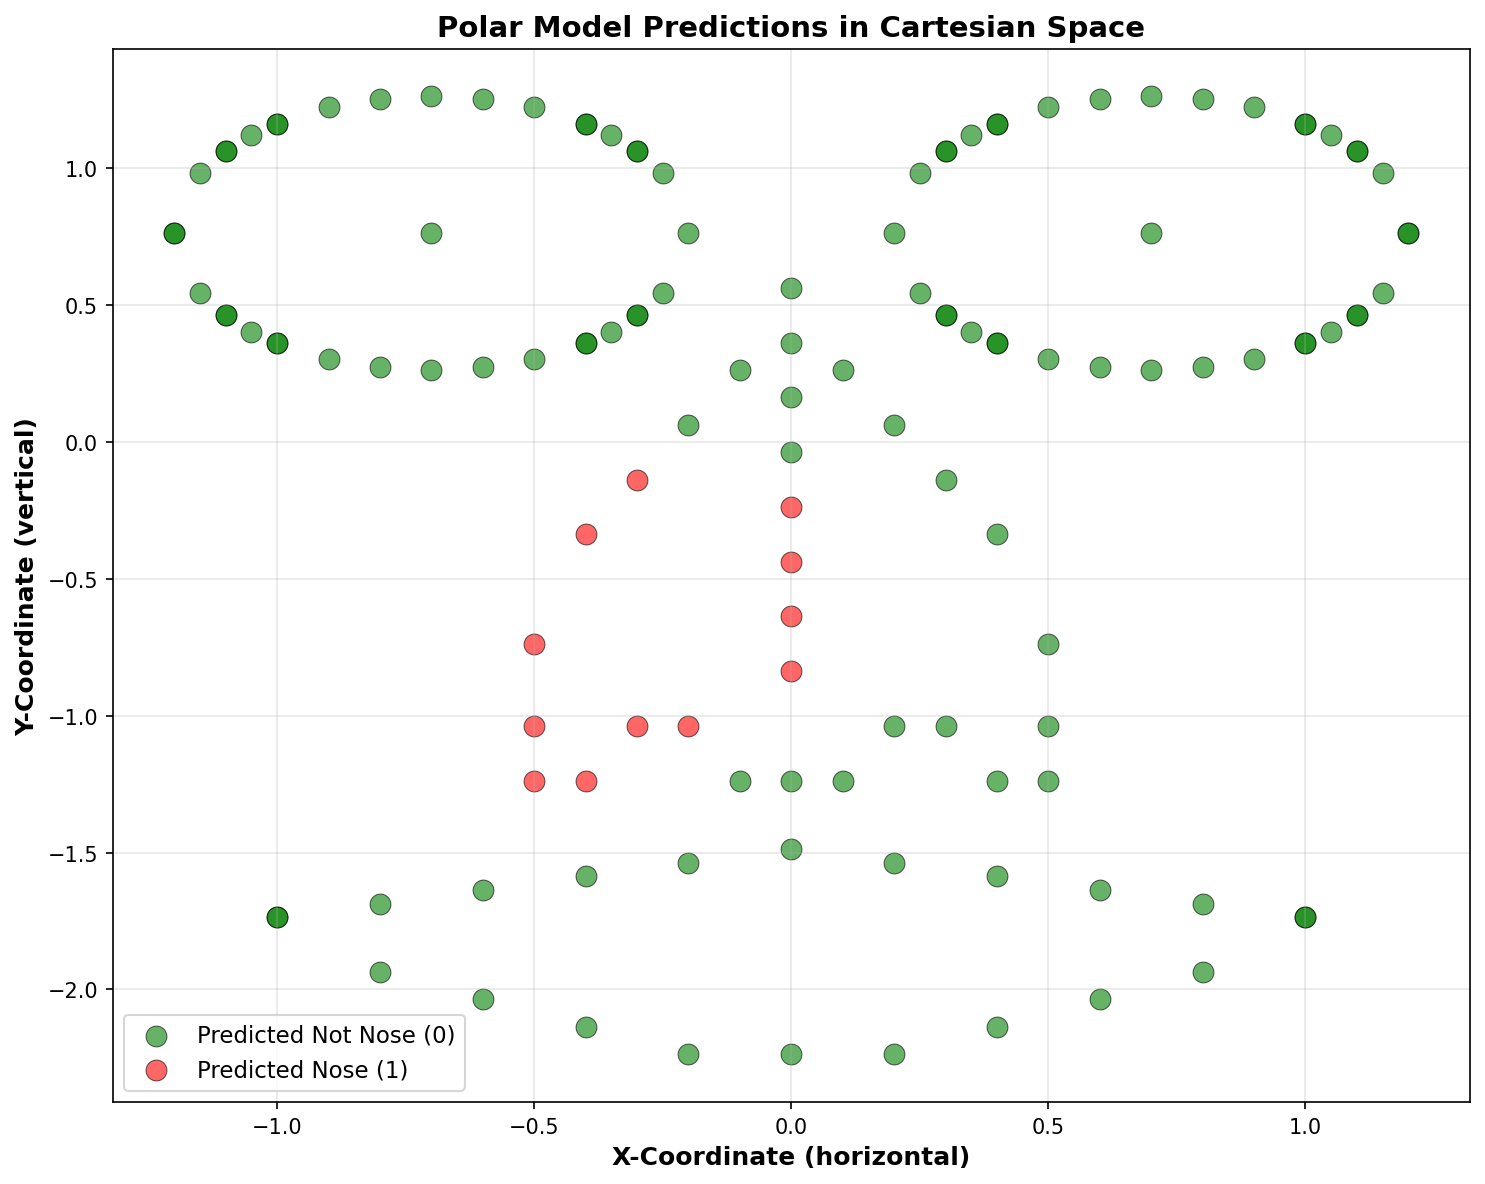

In [25]:
# Plot polar model predictions using original Cartesian coordinates (horizontal and vertical)
plt.figure(figsize=(10, 8), dpi=150)

# Plot points for each predicted class using Cartesian coordinates
for nose_class, color, label in [(0, 'green', 'Predicted Not Nose (0)'), (1, 'red', 'Predicted Nose (1)')]:
    mask = y_pred_polar == nose_class
    plt.scatter(face.loc[mask, 'horizontal'], face.loc[mask, 'vertical'], 
                c=color, label=label, s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('X-Coordinate (horizontal)', fontsize=12, fontweight='bold')
plt.ylabel('Y-Coordinate (vertical)', fontsize=12, fontweight='bold')
plt.title('Polar Model Predictions in Cartesian Space', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Prof code below

Optimization terminated successfully.
         Current function value: 0.659828
         Iterations 4
                          MNLogit Regression Results                          
Dep. Variable:                IS_NOSE   No. Observations:                  129
Model:                        MNLogit   Df Residuals:                      127
Method:                           MLE   Df Model:                            1
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                 -0.1966
Time:                        14:26:07   Log-Likelihood:                -85.118
converged:                       True   LL-Null:                       -71.135
Covariance Type:            nonrobust   LLR p-value:                     1.000
 IS_NOSE=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
horizontal  1.403e-17      0.270    5.2e-17      1.000      -0.528       0.528
vertical      -0.4964      0.

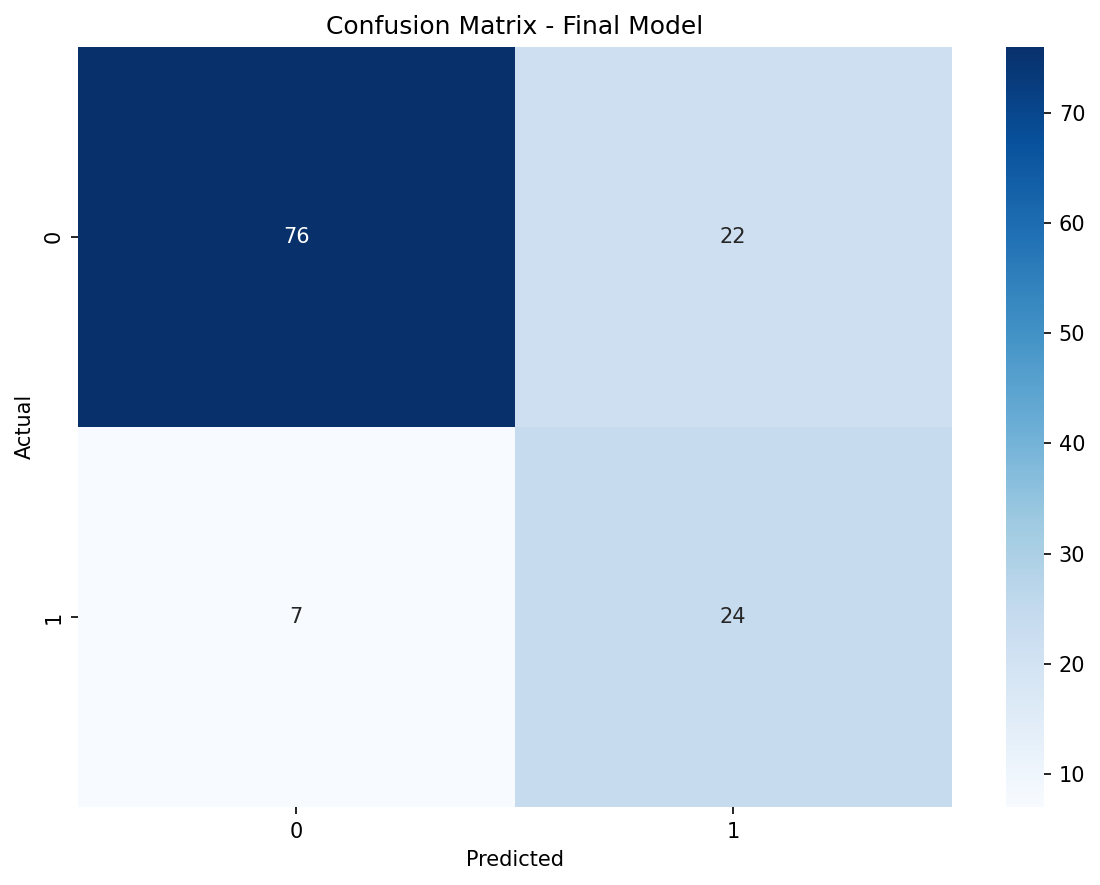

In [ ]:
result_list = Utility.MNLogisticModel (X0_train, y_train)
thisFit = result_list[0]
print(thisFit.summary())

# Plot confusion matrix for thisFit model
pred_probs = thisFit.predict(X0_train)
y_pred = pred_probs.idxmax(axis=1)

cm = confusion_matrix(y_train, y_pred)

plt.figure(figsize=(8, 6), dpi=150)
seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



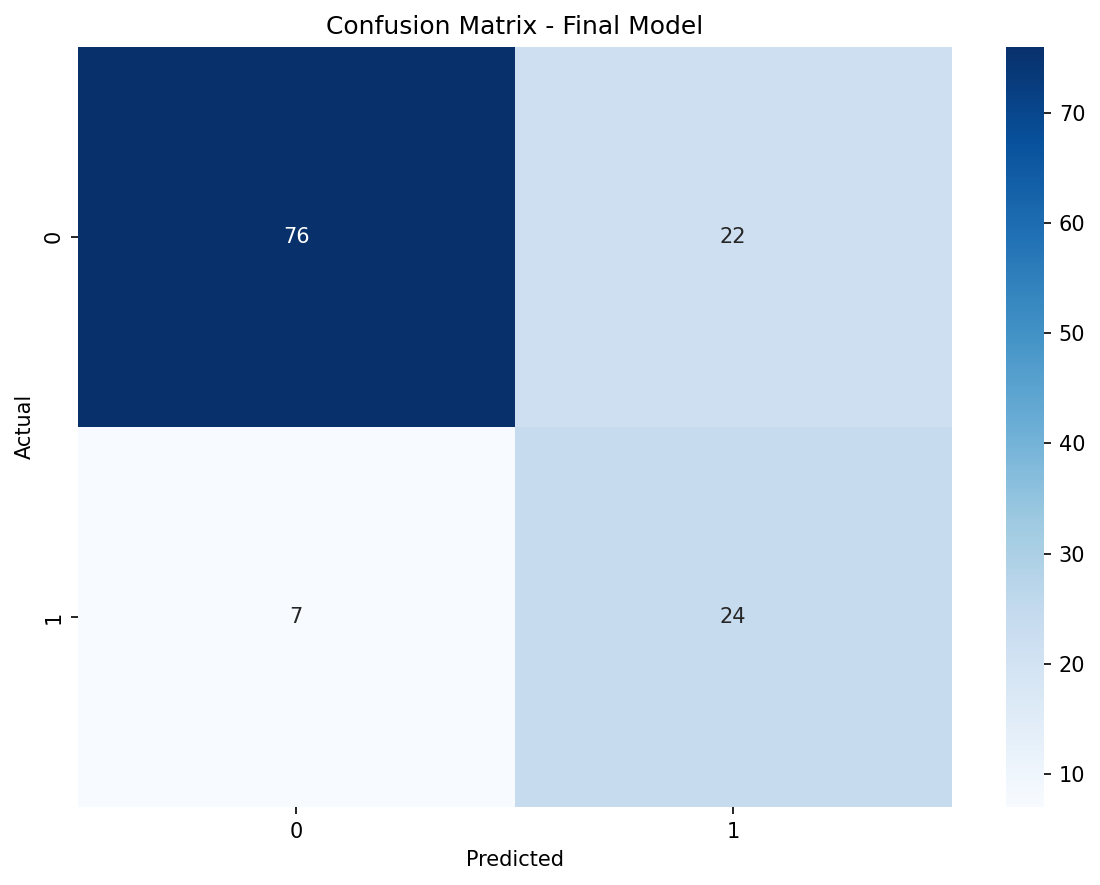

In [132]:
# Generate predictions from the logit model
pred_probs = nose_model.predict(X_train)
y_pred_nose = (pred_probs > 0.5).astype(int)

# Create color mapping: RED for nose (1), GREEN for not nose (0)
colors = ['green' if val == 0 else 'red' for val in y_pred_nose]

# Create scatter plot
plt.figure(figsize=(10, 8), dpi=150)
for nose_class, color, label in [(0, 'green', 'Not Nose (0)'), (1, 'red', 'Nose (1)')]:
    mask = y_pred_nose == nose_class
    plt.scatter(face.loc[mask, 'horizontal'], face.loc[mask, 'vertical'], 
                c=color, label=label, s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('X-Coordinate (horizontal)', fontsize=12)
plt.ylabel('Y-Coordinate (vertical)', fontsize=12)
plt.title('Predicted Nose vs Non-Nose Locations', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: Cannot index with multidimensional key

<Figure size 1500x1200 with 0 Axes>

In [54]:
success = pandas.read_csv(r'data\Student Academic Success.csv', delimiter = ';') 
success.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.0000000000,0,0,0,0,0,0.0000000000,0,10.8000000000,1.4000000000,1.7400000000,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.0000000000,0,0,6,6,6,13.6666666667,0,13.9000000000,-0.3000000000,0.7900000000,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.0000000000,0,0,6,0,0,0.0000000000,0,10.8000000000,1.4000000000,1.7400000000,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.4285714286,0,0,6,10,5,12.4000000000,0,9.4000000000,-0.8000000000,-3.1200000000,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.3333333333,0,0,6,6,6,13.0000000000,0,13.9000000000,-0.3000000000,0.7900000000,Graduate


In [55]:
print(success.groupby('Target').size())

Target
Dropout     1421
Enrolled     794
Graduate    2209
dtype: int64


In [56]:
success['Dropout'] = success['Target'].map({'Dropout': 'Yes', 'Enrolled': 'No', 'Graduate': 'No'})
q_dropout_count = success.groupby('Dropout').size()
q_dropout_odds = q_dropout_count['Yes'] / q_dropout_count['No']

In [57]:
success['Attendance'] = success['Daytime/evening attendance'].map({0: 'Evening', 1: 'Daytime'})
success['Debtor'] = success['Debtor'].map({0: 'No', 1: 'Yes'})
success['Scholarship holder'] = success['Scholarship holder'].map({0: 'No', 1: 'Yes'})

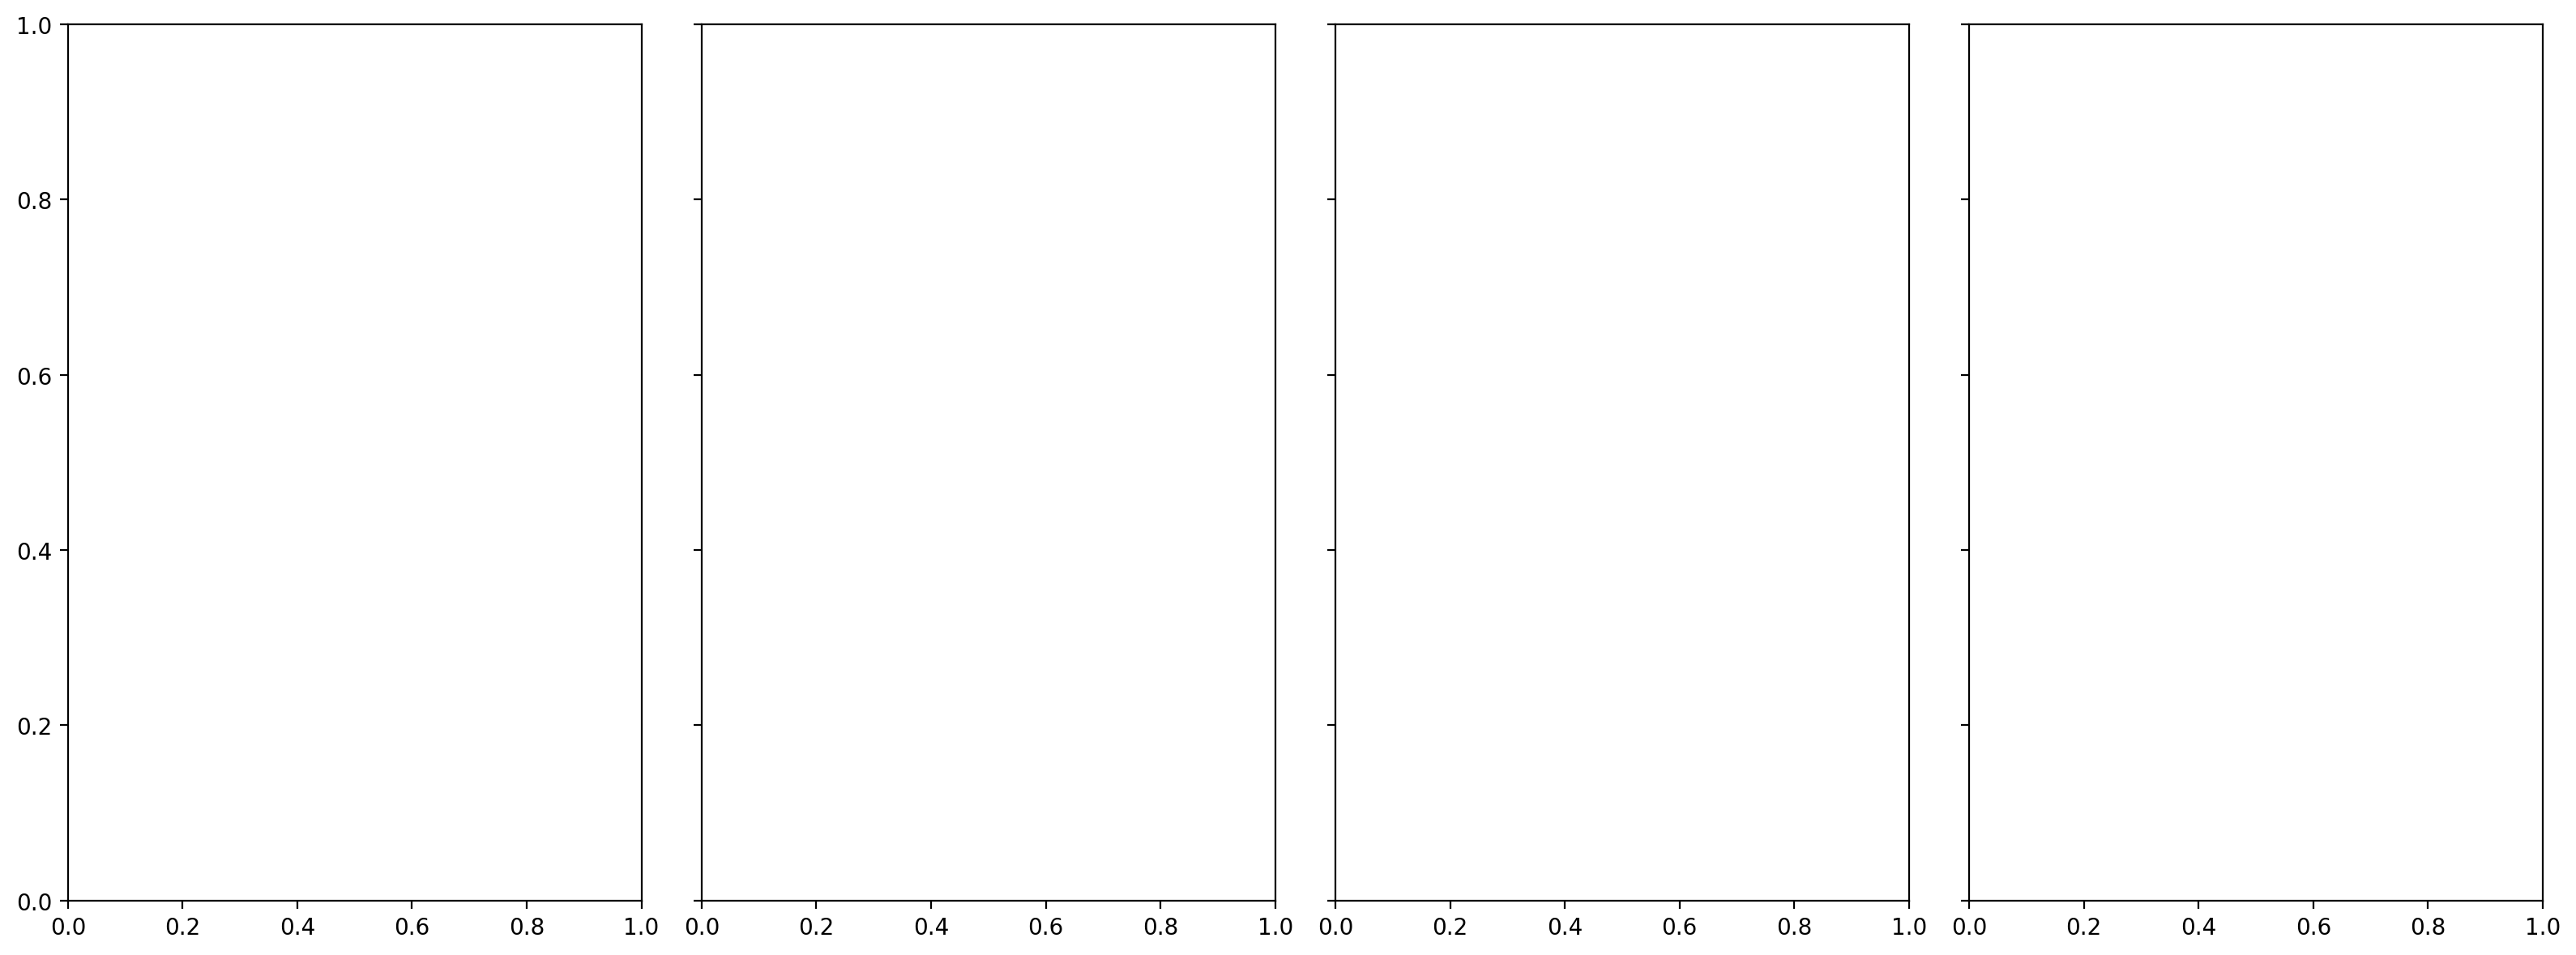

In [58]:
# Univariate frequency bar charts
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows = 1, ncols = 4, dpi = 200, sharey = True, figsize = (16,6))
fig.tight_layout()

In [59]:
ufreq = success['Dropout'].astype('category').value_counts()
ax1.bar(ufreq.index, ufreq, color = 'red')
ax1.set_xlabel('Drop Out College?')
ax1.set_ylabel('Number of Observations')
ax1.set_yticks(range(0, 4500, 500))
ax1.yaxis.grid(True)

In [60]:
ufreq = success['Attendance'].astype('category').value_counts()
ax2.bar(ufreq.index, ufreq, color = 'dodgerblue')
ax2.set_xlabel('Mode of Attendance')
ax2.set_ylabel('')
ax2.yaxis.grid(True)

In [61]:
ufreq = success['Debtor'].astype('category').value_counts()
ax3.bar(ufreq.index, ufreq, color = 'orange')
ax3.set_xlabel('Owe Debt?')
ax3.set_ylabel('')
ax3.yaxis.grid(True)

In [62]:
ufreq = success['Scholarship holder'].astype('category').value_counts()
ax4.bar(ufreq.index, ufreq, color = 'green')
ax4.set_xlabel('Hold Scholarship?')
ax4.set_ylabel('')
ax4.yaxis.grid(True)

In [63]:
plt.show()

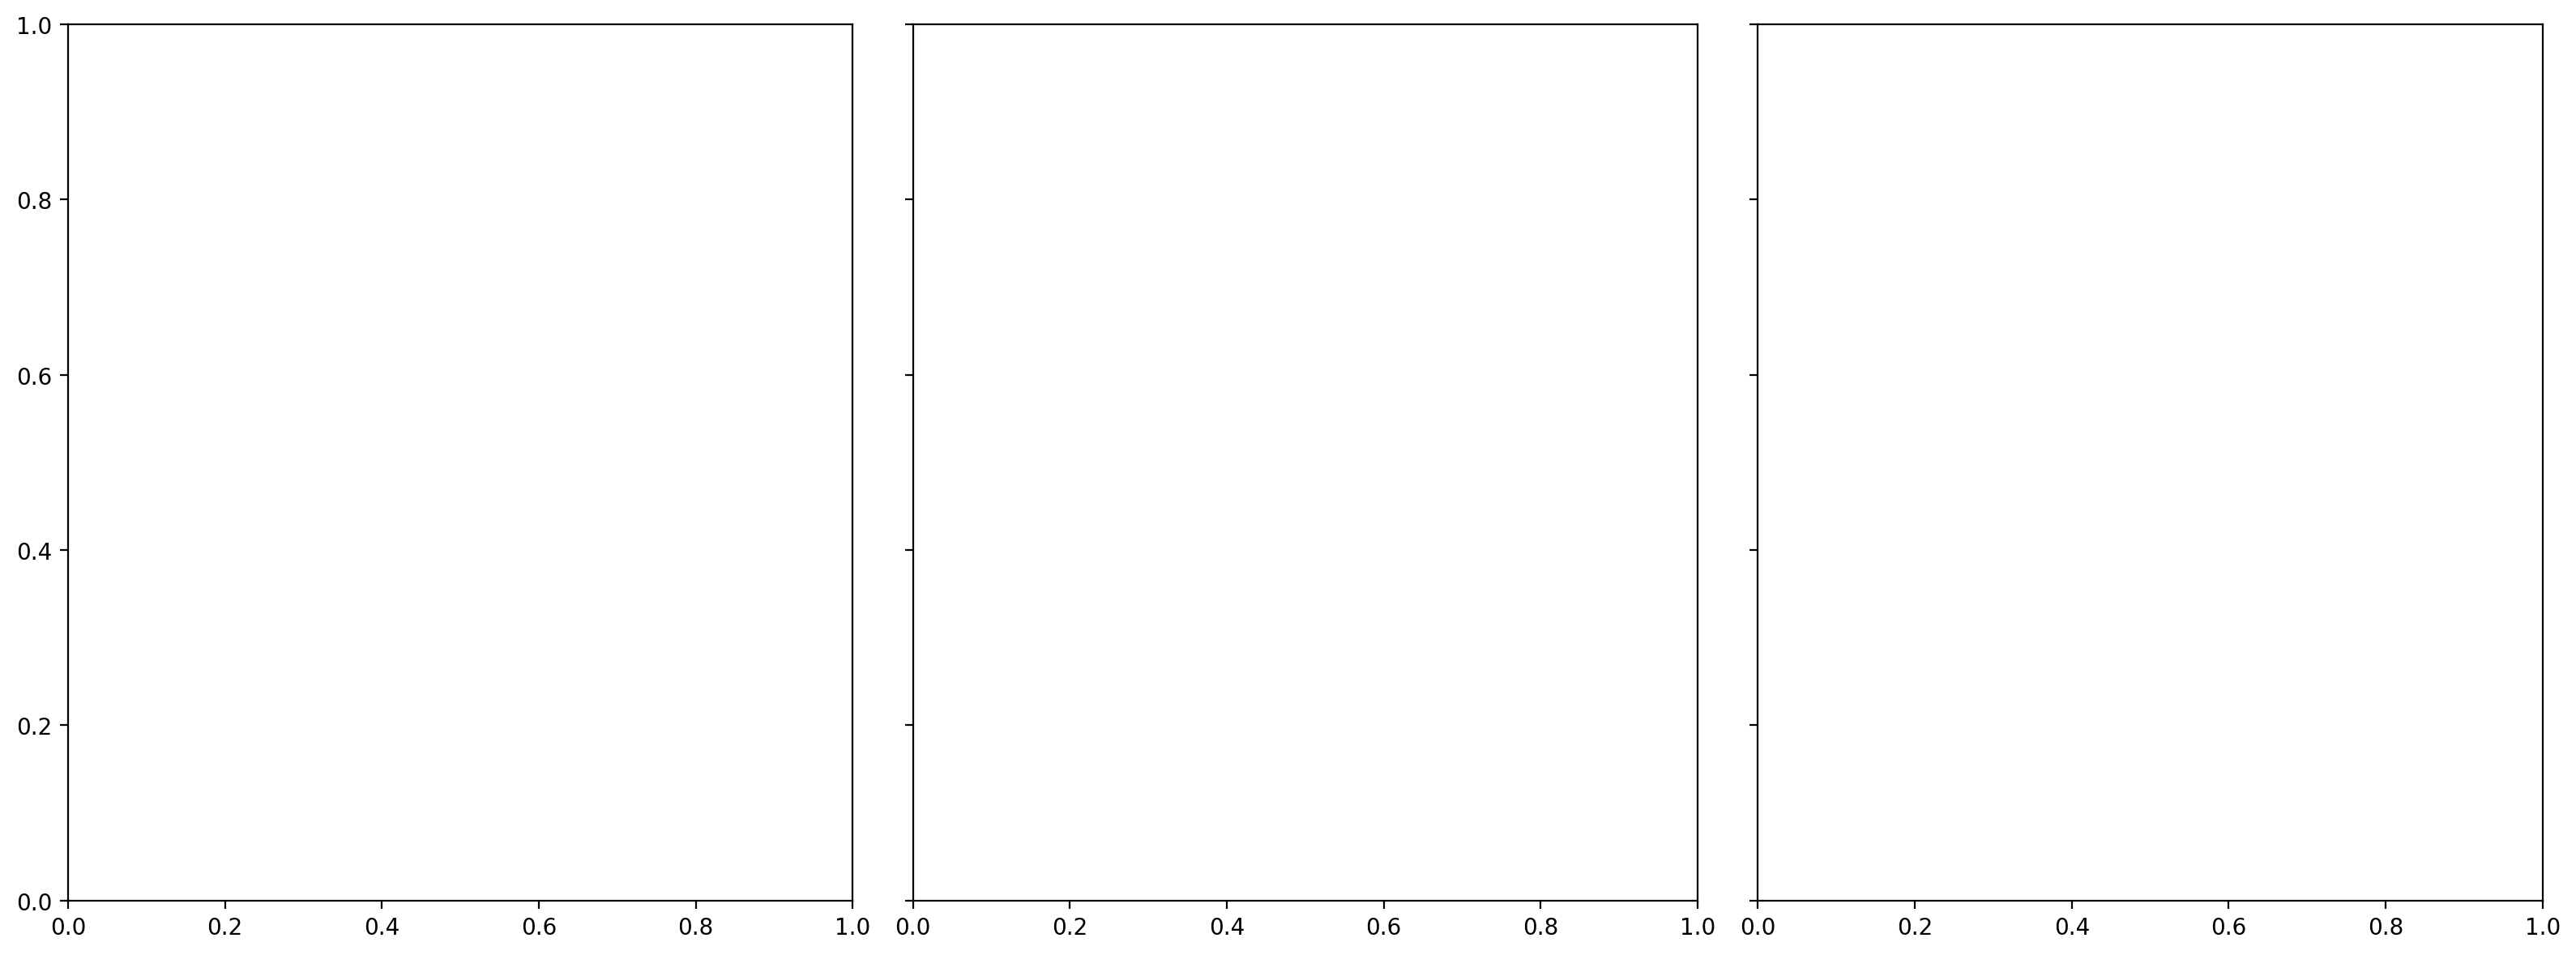

In [64]:
# Univariate odds of dropout
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, dpi = 200, sharey = True, figsize = (16,6))
fig.tight_layout()

In [65]:
xtab = pandas.crosstab(success['Attendance'], success['Dropout'])
odds_table =  xtab['Yes'] / xtab['No']

In [66]:
ax1.bar(odds_table.index, odds_table, color = 'dodgerblue')
ax1.axhline(y = q_dropout_odds, color = 'red', linestyle = '--')
ax1.set_xlabel('Mode of Attendance')
ax1.set_ylabel('Dropout Odds = Yes/No')
ax1.yaxis.grid(True)

In [67]:
xtab = pandas.crosstab(success['Debtor'], success['Dropout'])
odds_table =  xtab['Yes'] / xtab['No']

In [68]:
ax2.bar(odds_table.index, odds_table, color = 'orange')
ax2.axhline(y = q_dropout_odds, color = 'red', linestyle = '--')
ax2.set_xlabel('Owe Debt?')
ax2.set_ylabel('')
ax2.yaxis.grid(True)

In [69]:
xtab = pandas.crosstab(success['Scholarship holder'], success['Dropout'])
odds_table =  xtab['Yes'] / xtab['No']

In [70]:
ax3.bar(odds_table.index, odds_table, color = 'green')
ax3.axhline(y = q_dropout_odds, color = 'red', linestyle = '--')
ax3.set_xlabel('Hold Scholarship?')
ax3.set_ylabel('')
ax3.yaxis.grid(True)

In [71]:
plt.show()

In [72]:
xtab = pandas.crosstab(success['Age at enrollment'], success['Dropout'])
print(xtab)

Dropout             No  Yes
Age at enrollment          
17                   5    0
18                 834  202
19                 704  207
20                 466  133
21                 229   93
22                 116   58
23                  67   41
24                  75   56
25                  46   47
26                  42   52
27                  36   55
28                  36   47
29                  21   45
30                  19   30
31                  19   36
32                  28   33
33                  25   20
34                  31   29
35                  20   29
36                  14   21
37                  19   23
38                  10   19
39                  20   18
40                  10   13
41                  20   11
42                   6    7
43                  14   11
44                  11   10
45                   9   13
46                   6    6
47                   7   11
48                   4    7
49                   6    7
50                  

In [73]:
odds_table =  xtab['Yes'] / xtab['No']

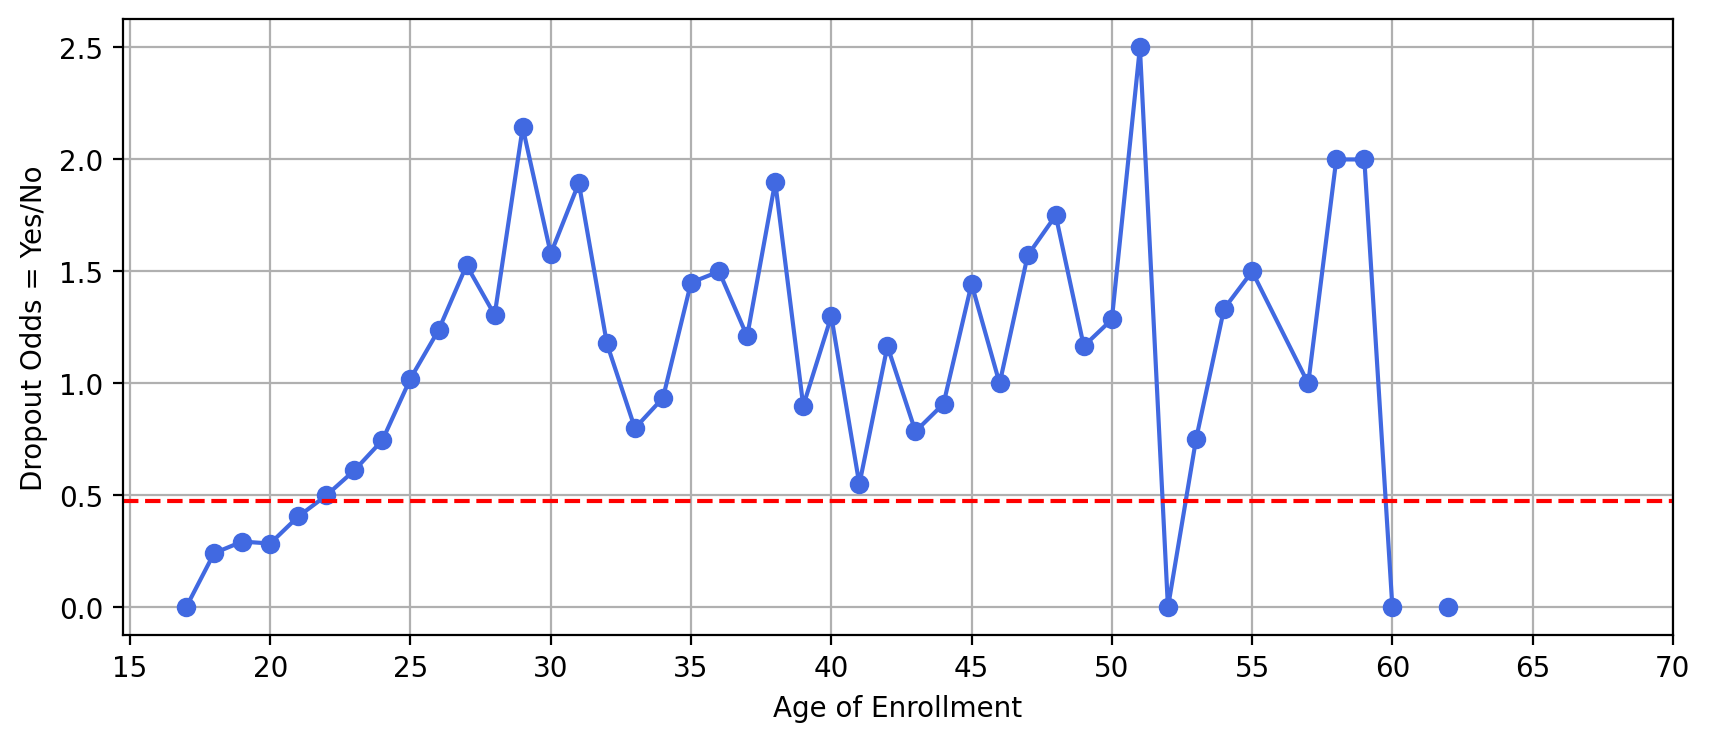

In [74]:
plt.figure(figsize = (10,4), dpi = 200)
plt.plot(odds_table.index, odds_table, marker = 'o', color = 'royalblue')
plt.axhline(y = q_dropout_odds, color = 'red', linestyle = '--')
plt.xlabel('Age of Enrollment')
plt.ylabel('Dropout Odds = Yes/No')
plt.xticks(numpy.arange(15,75,5))
plt.grid(axis = 'both')
plt.show()

In [75]:
# Forward Selection
catName = ['Attendance', 'Debtor', 'Scholarship holder']
intName = ['Age at enrollment']
yName = 'Dropout'
yCat = ['No', 'Yes']

In [76]:
train_data = success[catName + intName + [yName]]

In [77]:
train_data

,Attendance,Debtor,Scholarship holder,Age at enrollment,Dropout
0,Daytime,No,No,20,Yes
1,Daytime,No,No,19,No
2,Daytime,No,No,19,Yes
3,Daytime,No,No,20,No
4,Evening,No,No,45,No
...,...,...,...,...,...
4419,Daytime,No,No,19,No
4420,Daytime,Yes,No,18,Yes
4421,Daytime,No,Yes,30,Yes
4422,Daytime,No,Yes,20,No


In [78]:
step_diary = []
y_train = train_data[yName]

In [98]:
y_train

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
4419     No
4420    Yes
4421    Yes
4422     No
4423     No
Name: Dropout, Length: 4424, dtype: object

In [79]:
# Intercept only model
X0_train = train_data[[]].copy()
X0_train.insert(0, 'Intercept', 1.0)

In [80]:
result_list = Utility.MNLogisticModel (X0_train, y_train)
n_iter = result_list[0].mle_retvals['iterations']
llk0 = result_list[1]
df0 = result_list[2]

Optimization terminated successfully.
         Current function value: 0.627773
         Iterations 4


In [81]:
step_diary.append([0, 'Intercept', ' ', n_iter, df0, llk0, numpy.nan, numpy.nan, numpy.nan])

In [82]:
entryThreshold = 0.05

In [83]:
cName = catName.copy()
iName = intName.copy()
nPredictor = len(cName) + len(iName)

In [84]:
# The Deviance significance is the eighth element in each row of the test result
def takeDevSig(s):
    return s[7]

In [85]:
for step in range(nPredictor):
    enterName = ''

    # Columns are 'Predictor', 'Type', 'N Iter', 'ModelDF', 'ModelLLK', 'DevChiSq', 'DevDF', 'DevSig'
    step_detail = []

    # Enter the next predictor
    for X_name in cName:
        X_train = X0_train.join(pandas.get_dummies(train_data[[X_name]].astype('category'), dtype = float))
        result_list = Utility.MNLogisticModel (X_train, y_train)
        n_iter = result_list[0].mle_retvals['iterations']
        llk1 = result_list[1]
        df1 = result_list[2]
        devChiSq = 2.0 * (llk1 - llk0)
        devDF = df1 - df0
        devSig = chi2.sf(devChiSq, devDF)
        step_detail.append([X_name, 'categorical', n_iter, df1, llk1, devChiSq, devDF, devSig])

    for X_name in iName:
        X_train = X0_train.join(train_data[[X_name]])
        result_list = Utility.MNLogisticModel (X_train, y_train)
        n_iter = result_list[0].mle_retvals['iterations']
        llk1 = result_list[1]
        df1 = result_list[2]
        devChiSq = 2.0 * (llk1 - llk0)
        devDF = df1 - df0
        devSig = chi2.sf(devChiSq, devDF)
        step_detail.append([X_name, 'interval', n_iter, df1, llk1, devChiSq, devDF, devSig])

    # Find a predictor to add, if any
    step_detail.sort(key = takeDevSig, reverse = False)
    minSig = takeDevSig(step_detail[0])
    if (minSig <= entryThreshold):
        add_var = step_detail[0][0]
        add_type = step_detail[0][1]
        df0 = step_detail[0][3]
        llk0 = step_detail[0][4]
        step_diary.append([step+1] + step_detail[0])
        if (add_type == 'categorical'):
           X0_train = X0_train.join(pandas.get_dummies(train_data[[add_var]].astype('category'), dtype = float))
           cName.remove(add_var)
        else:
           X0_train = X0_train.join(train_data[[add_var]])
           iName.remove(add_var)           
    else:
        break

Optimization terminated successfully.
         Current function value: 0.624665
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.603379
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.593721
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.597097
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.592099
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.571697
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.572282
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.569812
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.552984
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.552509
  

In [86]:
# End of forward selection
print('\n======= Step Summary =======')
step_diary = pandas.DataFrame(step_diary, columns = ['Step', 'Predictor', 'Type', 'N Iter', 'ModelDF', \
                              'ModelLLK', 'DevChiSq', 'DevDF', 'DevSig'])
print(step_diary)


======= Step Summary =======
   Step           Predictor         Type  N Iter  ModelDF          ModelLLK       DevChiSq        DevDF       DevSig
0     0           Intercept                    4        1 -2,777.2658559465            NaN          NaN          NaN
1     1  Scholarship holder  categorical       5        2 -2,626.6211940628 301.2893237673 1.0000000000 0.0000000000
2     2              Debtor  categorical       6        3 -2,529.1858155592 194.8707570073 1.0000000000 0.0000000000
3     3   Age at enrollment     interval       6        4 -2,446.4033618084 165.5649075016 1.0000000000 0.0000000000
4     4          Attendance  categorical       6        5 -2,444.2981338310   4.2104559547 1.0000000000 0.0401755367


In [87]:
# Retrain the final model
result_list = Utility.MNLogisticModel (X0_train, y_train)
thisFit = result_list[0]

Optimization terminated successfully.
         Current function value: 0.552509
         Iterations 6


In [101]:
y_train


0       Yes
1        No
2       Yes
3        No
4        No
       ... 
4419     No
4420    Yes
4421    Yes
4422     No
4423     No
Name: Dropout, Length: 4424, dtype: object

In [88]:
print(thisFit.summary())

                          MNLogit Regression Results                          
Dep. Variable:                Dropout   No. Observations:                 4424
Model:                        MNLogit   Df Residuals:                     4419
Method:                           MLE   Df Model:                            4
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.1199
Time:                        10:19:29   Log-Likelihood:                -2444.3
converged:                       True   LL-Null:                       -2777.3
Covariance Type:            nonrobust   LLR p-value:                8.273e-143
          Dropout=Yes       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -2.3410      0.233    -10.034      0.000      -2.798      -1.884
Scholarship holder_No     1.3392      0.102     13.077      0.000       1.138       1.540
Debtor_N

In [89]:
beta =  thisFit.params
aliasParam = result_list[4]
nonAliasParam = result_list[5]

In [90]:
print('=== Aliased Columns in Model Matrix X ===')
print(X0_train.columns[aliasParam])

=== Aliased Columns in Model Matrix X ===
Index(['Scholarship holder_Yes', 'Debtor_Yes', 'Attendance_Evening'], dtype='object')


In [91]:
llk1 = thisFit.llf
llk0 = thisFit.llnull
n_sample = X0_train.shape[0]

In [92]:
R_MF = 1.0 - (llk1 / llk0)

In [93]:
R_CS = (2.0 / n_sample) * (llk0 - llk1)
R_CS = 1.0 - numpy.exp(R_CS)

In [94]:
upbound = (2.0 / n_sample) * llk0
upbound = 1.0 - numpy.exp(upbound)
R_N = R_CS / upbound

In [95]:
predprob_event = thisFit.predict(X0_train.iloc[:, list(nonAliasParam)])[1]

In [96]:
S1 = numpy.mean(predprob_event[y_train == 'Yes'])
S0 = numpy.mean(predprob_event[y_train == 'No'])

In [97]:
R_TJ = S1 - S0